# **Start**

In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install gpboost
!pip install ngboost
!pip install bayesian-optimization
!pip install optuna
!pip install hyperopt
!pip install tensorflow
!pip install keras
!pip install keras-tuner

  Using cached hyperopt-0.2.7-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
Using cached hyperopt-0.2.7-py2.py3-none-any.whl (1.6 MB)
Using cached future-1.0.0-py3-none-any.whl (491 kB)
  Using cached keras_tuner-1.4.7-py3-none-any.whl.metadata (5.4 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.7-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,make_scorer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from gpboost import GPBoostRegressor
from ngboost import NGBRegressor
from bayes_opt import BayesianOptimization
import optuna
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import tensorflow as tf
from tensorflow import keras
from keras_tuner import Hyperband
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [5]:
train_data_path = r"C:\Users\Danesh\Desktop\Concrete\train.csv"
test_data_path = r"C:\Users\Danesh\Desktop\Concrete\test.csv"

In [6]:
train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)
print("Training data loaded successfully.")
print("Test data loaded successfully.")

Training data loaded successfully.
Test data loaded successfully.


In [7]:
print("\nShape of training data:", train_data.shape)
print("First 10 rows of training data:\n", train_data.head(5))
print("\nShape of test data:", test_data.shape)
print("First 10 rows of test data:\n", test_data.head(5))


Shape of training data: (189, 8)
First 10 rows of training data:
         C    mp     FA      CA       F       W_P    Adm    str
0  280.80  70.2  858.0  1183.0    0.00  0.450000  0.610  21.56
1  372.15   0.0  975.0   525.0   52.85  0.493081  7.000  34.00
2  360.00  75.0  975.0   525.0   40.00  0.509722  7.000  28.00
3  364.30   0.0  975.0   525.0  110.40  0.503706  7.000  42.00
4  315.00  31.5  780.0  1110.0    0.00  0.370000  5.355  25.82

Shape of test data: (95, 8)
First 10 rows of test data:
         C     mp     FA     CA      F       W_P   Adm   str
0  364.30    0.0  975.0  525.0  60.40  0.503706   7.0  34.0
1  344.30   75.0  975.0  525.0  55.40  0.532965   7.0  36.0
2  390.00    0.0  975.0  525.0  60.00  0.470513   7.0  36.0
3  352.15   75.0  975.0  525.0  47.85  0.521085   7.0  35.0
4  400.00  160.0  801.0  801.0  40.00  0.300000  10.3  44.6


In [8]:
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]
x_test= X_test
print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (189, 7)
Shape of y_train: (189,)
Shape of X_test: (95, 7)
Shape of y_test: (95,)


In [9]:
# Apply z-score normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Print the first five rows of the normalized data
print("\nFirst five rows of normalized X_train:")
print(X_train[:5])

print("\nFirst five rows of normalized X_test:")
print(X_test[:5])


First five rows of normalized X_train:
[[-1.56879184  0.95792014 -0.09685034  1.33138508 -0.85369002  0.16810471
  -0.08799752]
 [ 0.40300047 -0.7708921   0.73537613 -0.93459372  0.061075    0.78285857
  -0.0664621 ]
 [ 0.14074238  1.07612953  0.73537613 -0.93459372 -0.16134185  1.020321
  -0.0664621 ]
 [ 0.233558   -0.7708921   0.73537613 -0.93459372  1.05719093  0.93447436
  -0.0664621 ]
 [-0.83058388  0.00485698 -0.65166799  1.07999229 -0.85369002 -0.97347298
  -0.07200604]]

First five rows of normalized X_test:
[[ 0.233558   -0.7708921   0.73537613 -0.93459372  0.19175572  0.93447436
  -0.0664621 ]
 [-0.19814256  1.07612953  0.73537613 -0.93459372  0.1052122   1.35199213
  -0.0664621 ]
 [ 0.78829322 -0.7708921   0.73537613 -0.93459372  0.18483223  0.4608195
  -0.0664621 ]
 [-0.02870009  1.07612953  0.73537613 -0.93459372 -0.02546852  1.18246784
  -0.0664621 ]
 [ 1.0041435   3.1694207  -0.50229401  0.01587763 -0.16134185 -1.97235346
  -0.05534052]]


In [10]:
# Define the model classes
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'XGBoost': XGBRegressor,
    'LightGBM': LGBMRegressor,
    'GPBoost': GPBoostRegressor,
    'CatBoost': CatBoostRegressor,
    'SVM': SVR,
    'NGBoost': NGBRegressor
}

In [11]:
# Function to predict and save data.
def predict_and_save_results(results_dict, X_train, y_train, X_test, output_file_path):

    predictions_df = pd.read_csv(output_file_path)

    for model_name, model_info in results_dict.items():
        best_params = model_info['best_params']
        model_class = model_classes.get(model_name)

        if model_class is None:
            print(f"Model {model_name} is not supported or not available.")
            continue

        # Special handling for CatBoost to suppress verbose output
        if model_name == 'CatBoost':
            model = model_class(**best_params, verbose=0)
        else:
            model = model_class(**best_params)

        # Fit the model
        model.fit(X_train, y_train)

        # Make predictions
        predictions = model.predict(X_test)

        # Add predictions to DataFrame
        predictions_df[f'Sd_{model_name}'] = np.round(predictions, 2)

    # Save predictions to a CSV file at the specified location
    predictions_df.to_csv(output_file_path, index=False)
    print("Predictions have been added to the CSV file.")

In [12]:
# Function for plotting
def plot_best_scores(best_scores_ran):
    # Extract model names and their corresponding best test MSE, RMSE, and correlation coefficient scores
    model_names = list(best_scores_ran.keys())
    test_mse_scores = [best_scores_ran[model]['test_mse'] for model in model_names]
    test_rmse_scores = [best_scores_ran[model]['test_rmse'] for model in model_names]
    corr_coef_scores = [best_scores_ran[model]['test_corr_coef'] for model in model_names]

    # Plot 1: Bar chart for Test MSE
    plt.figure(figsize=(12, 6))
    bars = plt.bar(model_names, test_mse_scores, color='skyblue')

    # Highlight the best model
    best_model_index = np.argmin(test_mse_scores)
    bars[best_model_index].set_color('orange')

    # Annotate the bars with the test MSE scores
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                 f'{test_mse_scores[i]:.5f}', ha='center', va='bottom', color='black')

    # Add labels and title for the bar chart
    plt.xlabel('Model')
    plt.ylabel('Test MSE')
    plt.title('Best Test MSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot 2: Point-line graph for RMSE and Correlation Coefficient
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot RMSE scores
    ax1.set_xlabel('Model')
    ax1.set_ylabel('Test RMSE', color='tab:blue')
    ax1.plot(model_names, test_rmse_scores, marker='o', color='tab:blue', label='Test RMSE')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Create a second y-axis to plot the correlation coefficient
    ax2 = ax1.twinx()
    ax2.set_ylabel('Correlation Coefficient', color='tab:green')
    ax2.plot(model_names, corr_coef_scores, marker='x', color='tab:green', label='Correlation Coefficient')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    # Add a title and rotate x-axis labels for the point-line graph
    plt.title('Test RMSE and Correlation Coefficient for Each Model')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout(pad=2.0)
    plt.show()

# **Random SearchCV**

In [13]:
def hyperparameter_tuning_ran(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': [True, False],
            'copy_X': [True, False],
            'n_jobs': [-1, None],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': [None] + list(randint(1, 20).rvs(10)),
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 5),
            'max_features': [ 'sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 300],
            'max_depth': [None] + list(randint(1, 20).rvs(10)),
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 5),
            'max_features': [ 'sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': randint(1, 20),
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 5),
            'max_features': [ 'sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(verbosity= -1), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': randint(3, 10),
            'n_estimators': randint(100, 1000),
            'num_leaves': randint(15, 100),
            'min_child_samples': randint(1, 20),
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0]
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR(), {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7, 1.0]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        if model is None:
            print(f"Model {model_name} is not supported or not available.")
            continue

        print(f"Running RandomizedSearchCV for {model_name}...")
        try:
            search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run RandomizedSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_ran = hyperparameter_tuning_ran(X_train, y_train, X_test, y_test)

Running RandomizedSearchCV for Linear Regression...
Best MSE for Linear Regression: 51.11045031878047 with params: {'positive': True, 'n_jobs': -1, 'fit_intercept': True, 'copy_X': True}
Best RMSE for Linear Regression: 7.149157315291116
Correlation Coefficient for Linear Regression: 0.7000809884821552
Running RandomizedSearchCV for Decision Tree...
Best MSE for Decision Tree: 22.262814639926535 with params: {'max_depth': 6, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 9}
Best RMSE for Decision Tree: 4.718348719618605
Correlation Coefficient for Decision Tree: 0.8834291035963345
Running RandomizedSearchCV for Random Forest...
Best MSE for Random Forest: 15.7440646574354 with params: {'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 200}
Best RMSE for Random Forest: 3.9678791132587947
Correlation Coefficient for Random Forest: 0.9270580621421258
Running RandomizedSearchCV for Gradient Boosting...
Best MSE for Gr

In [14]:
output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_ran.csv"
predict_and_save_results(best_scores_ran, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=1.0. Current value: lambda_l2=1.0
[iter 0] loss=3.7185 val_loss=0.0000 scale=1.0000 norm=8.0786
[iter 100] loss=1.6046 val_loss=0.0000 scale=1.0000 norm=1.3174
[iter 200] loss=1.1366 val_loss=0.0000 scale=0.5000 norm=0.4627
Predictions have been added to the CSV file.


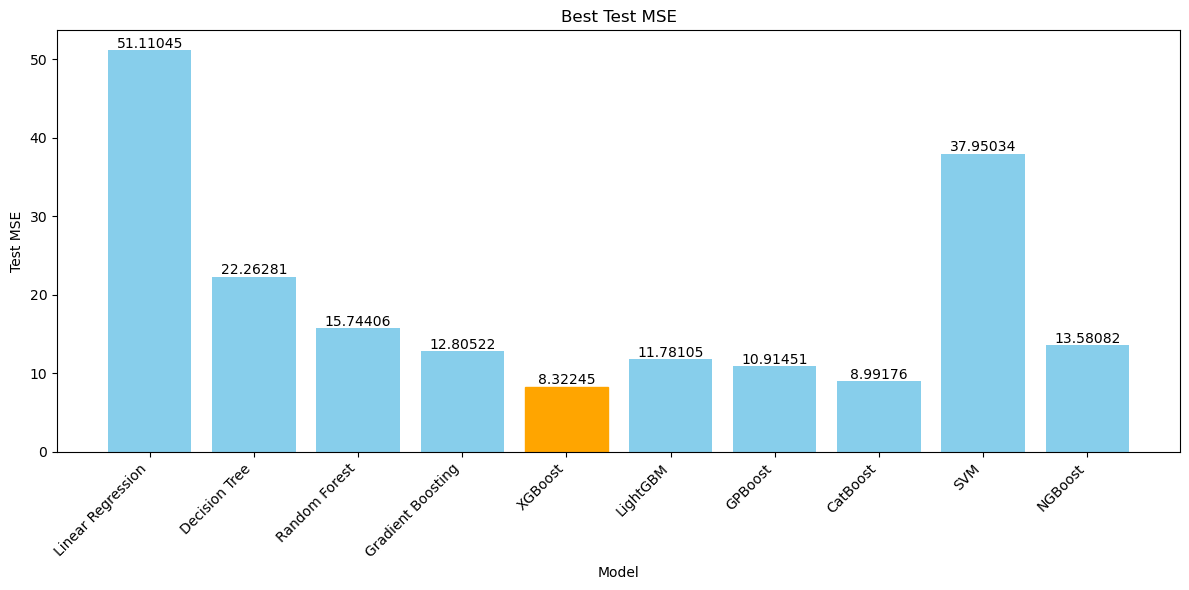

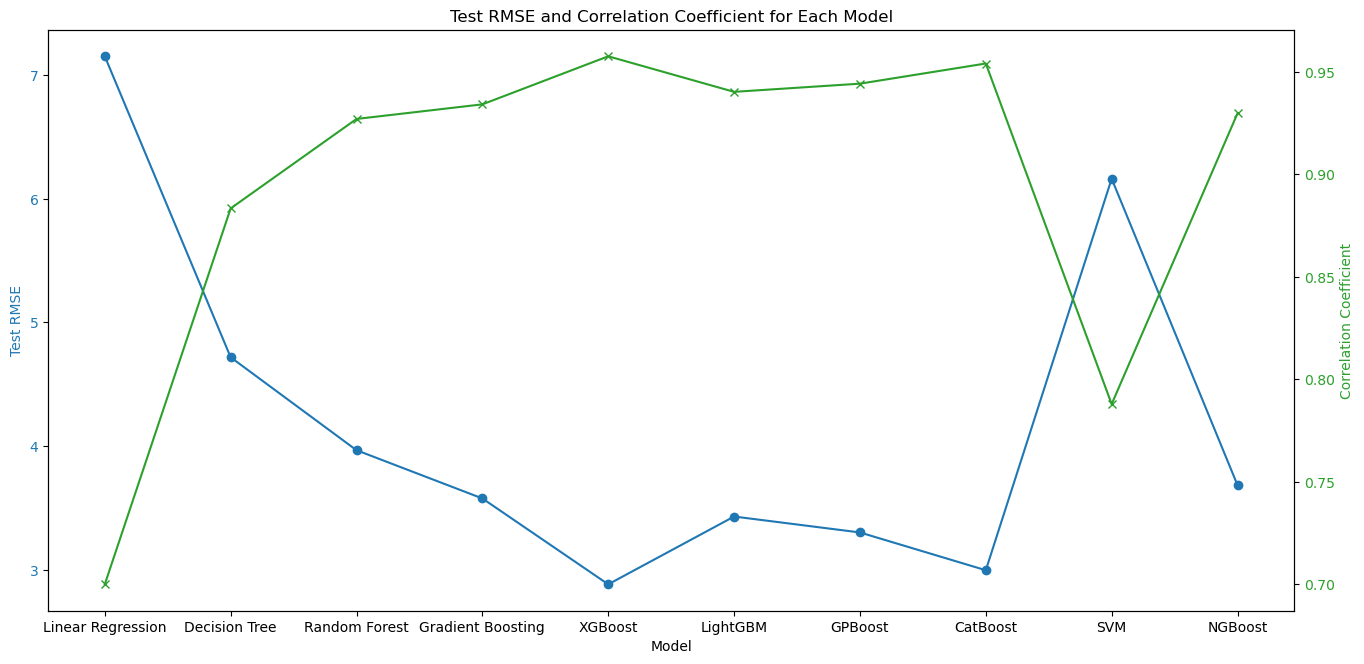

In [15]:
plot_best_scores(best_scores_ran)

# **Grid SearchCV**

In [16]:
def hyperparameter_tuning_grid(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': [True, False],
            'copy_X': [True, False],
            'n_jobs': [-1, None],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(verbosity=-1), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0]
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR(), {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        print(f"Running GridSearchCV for {model_name}...")
        try:
            search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run GridSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_grid = hyperparameter_tuning_grid(X_train, y_train, X_test, y_test)


Running GridSearchCV for Linear Regression...
Best MSE for Linear Regression: 51.11045031878047 with params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': True}
Best RMSE for Linear Regression: 7.149157315291116
Correlation Coefficient for Linear Regression: 0.7000809884821552
Running GridSearchCV for Decision Tree...
Best MSE for Decision Tree: 22.27235599387789 with params: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best RMSE for Decision Tree: 4.719359701683894
Correlation Coefficient for Decision Tree: 0.8953118664287864
Running GridSearchCV for Random Forest...
Best MSE for Random Forest: 10.382191338311117 with params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RMSE for Random Forest: 3.222140800509983
Correlation Coefficient for Random Forest: 0.9503969147534472
Running GridSearchCV for Gradient Boosting...
Best MSE for Gradient Boosting: 11.4

In [17]:
output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_grid.csv"
predict_and_save_results(best_scores_grid, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1
[iter 0] loss=3.7058 val_loss=0.0000 scale=1.0000 norm=7.9351
[iter 100] loss=1.4284 val_loss=0.0000 scale=1.0000 norm=1.1003
Predictions have been added to the CSV file.


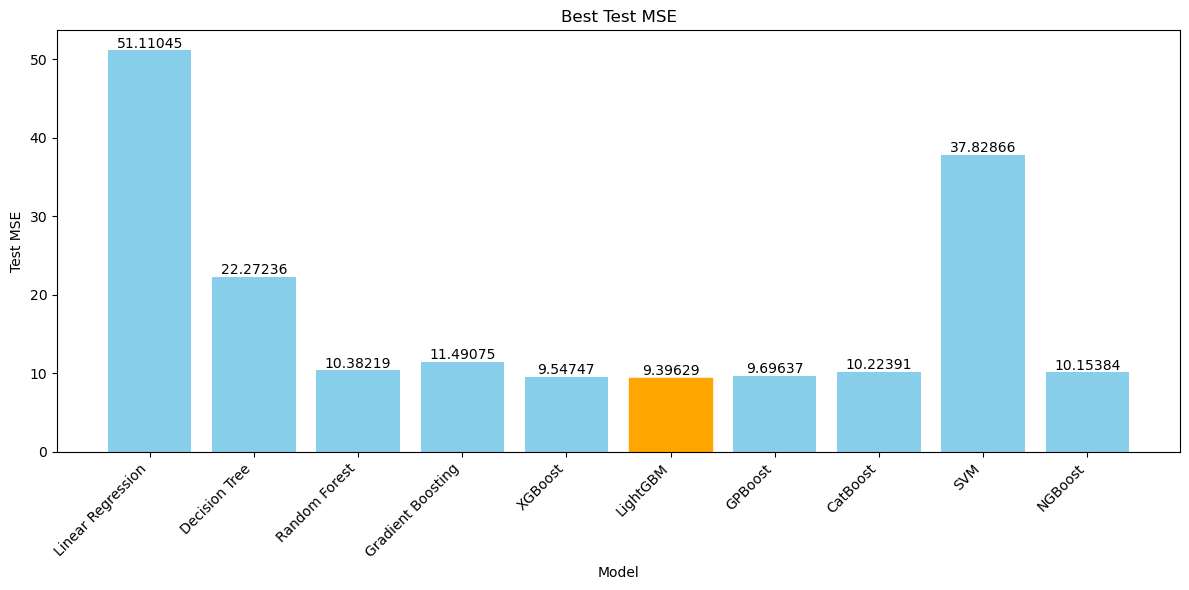

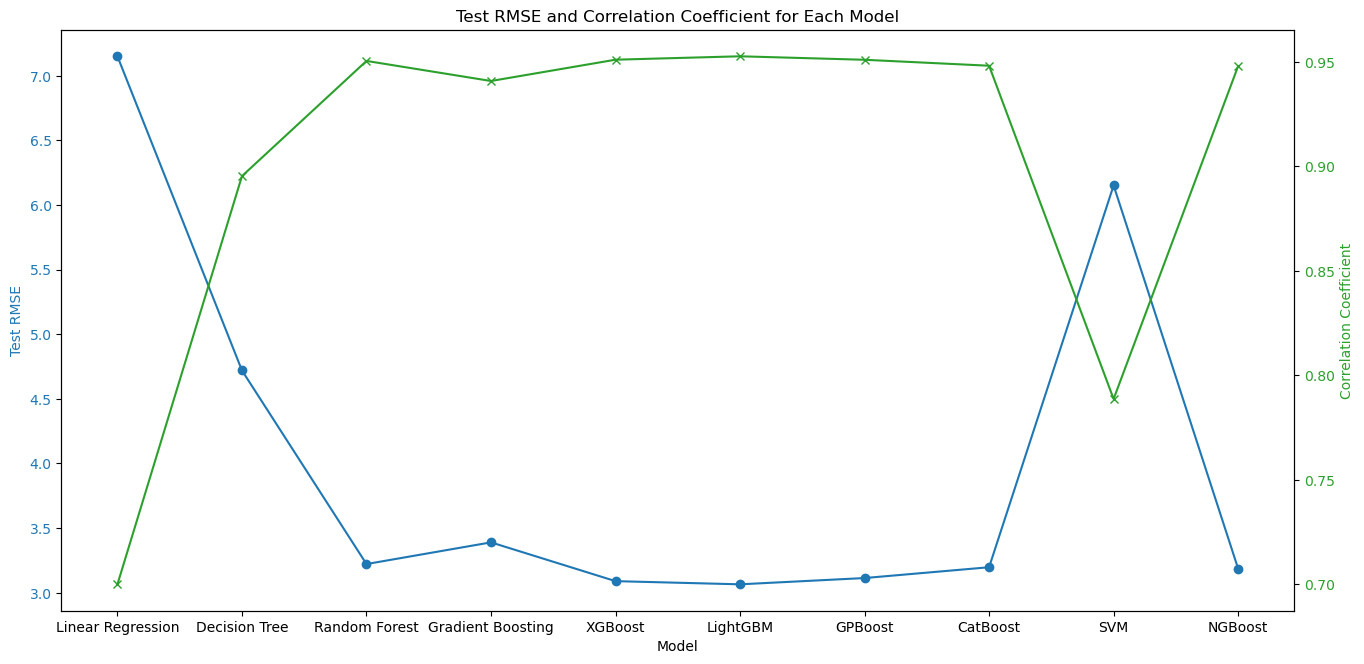

In [18]:
plot_best_scores(best_scores_ran= best_scores_grid)

# **Bayesian Optimization**

In [19]:
def hyperparameter_tuning_bayes_opt(X_train, y_train, X_test, y_test):
    def optimize_model(model, param_bounds, X_train, y_train):
        def objective(**params):
            # Convert parameters to the correct types
            for key in params:
                if key in ['fit_intercept', 'positive']:
                    params[key] = bool(round(params[key]))
                elif key in ['max_depth', 'min_samples_split', 'min_samples_leaf', 'n_estimators', 'iterations', 'num_leaves', 'degree', 'min_child_samples','depth']:
                    params[key] = int(round(params[key]))

            model.set_params(**params)
            # Use cross-validation to evaluate the model
            scores = cross_val_score(model, X_train, y_train, cv=3, scoring=make_scorer(mean_squared_error, greater_is_better=False))
            return np.mean(scores)

        optimizer = BayesianOptimization(f=objective, pbounds=param_bounds, random_state=42, verbose=2)
        optimizer.maximize(init_points=5, n_iter=20)
        return optimizer.max

    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': (0, 1),
            'positive': (0, 1)
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 11),
            'min_samples_leaf': (1, 5)
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': (100, 300),
            'max_depth': (1, 20),
            'min_samples_split': (2, 11),
            'min_samples_leaf': (1, 5)
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': (100, 500),
            'learning_rate': (0.01, 0.2),
            'max_depth': (1, 20),
            'min_samples_split': (2, 11),
            'min_samples_leaf': (1, 5)
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': (0.01, 0.1),
            'max_depth': (3, 7),
            'n_estimators': (100, 500),
            'min_child_weight': (1, 5),
            'gamma': (0, 1),
            'subsample': (0.5, 0.9),
            'colsample_bytree': (0.5, 0.9)
        }),
        'LightGBM': (LGBMRegressor(verbosity=-1), {
            'learning_rate': (0.01, 0.1),
            'max_depth': (3, 7),
            'n_estimators': (100, 500),
            'num_leaves': (15, 63),
            'min_child_samples': (1, 10),
            'subsample': (0.5, 0.9),
            'colsample_bytree': (0.5, 0.9)
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': (0.01, 0.1),
            'max_depth': (3, 7),
            'n_estimators': (100, 500),
            'num_leaves': (15, 63),
            'min_child_samples': (1, 10),
            'subsample': (0.5, 0.9),
            'colsample_bytree': (0.5, 0.9),
            'alpha': (0.1, 1.0),
            'lambda': (0.1, 1.0)
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': (0.01, 0.1),
            'iterations': (100, 500),
            'depth': (3, 7),
            'l2_leaf_reg': (1, 5)
        }),
        'SVM': (SVR(), {
            'C': (0.1, 10),
            'gamma': (0.01, 1),
            'degree': (2, 4),
            'epsilon': (0.01, 1)
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': (100, 300),
            'learning_rate': (0.01, 0.1),
            'minibatch_frac': (0.5, 1.0)
        })
    }

    best_scores = {}
    for model_name, (model, param_bounds) in models.items():
        print(f"Running Bayesian Optimization for {model_name}...")
        try:
            best_result = optimize_model(model, param_bounds, X_train, y_train)
            best_params = best_result['params']

            # Convert parameters to the correct types for final model fitting
            for key in best_params:
                if key in ['fit_intercept', 'copy_X', 'positive']:
                    best_params[key] = bool(round(best_params[key]))
                elif key in ['max_depth', 'min_samples_split', 'min_samples_leaf', 'n_estimators', 'iterations', 'num_leaves', 'degree', 'min_child_samples', 'depth']:
                    best_params[key] = int(round(best_params[key]))

            model.set_params(**best_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': -best_result['target'],
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Bayesian Optimization for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_bayes_opt = hyperparameter_tuning_bayes_opt(X_train, y_train, X_test, y_test)

Running Bayesian Optimization for Linear Regression...
|   iter    |  target   | fit_in... | positive  |
-------------------------------------------------
| 1         | -1.475e+0 | 0.3745    | 0.9507    |
| 2         | -73.92    | 0.732     | 0.5987    |
| 3         | -2.522e+0 | 0.156     | 0.156     |
| 4         | -1.475e+0 | 0.05808   | 0.8662    |
| 5         | -73.92    | 0.6011    | 0.7081    |
| 6         | -73.92    | 0.9997    | 0.9966    |
| 7         | -4.59e+05 | 0.9984    | 0.0003997 |
| 8         | -73.92    | 0.9998    | 0.7108    |
| 9         | -73.92    | 0.699     | 0.6204    |
| 10        | -73.92    | 0.6952    | 0.9958    |
| 11        | -1.475e+0 | 0.01026   | 0.9967    |
| 12        | -73.92    | 0.8145    | 0.7972    |
| 13        | -1.475e+0 | 0.2988    | 0.678     |
| 14        | -1.475e+0 | 0.002237  | 0.6222    |
| 15        | -1.475e+0 | 0.1686    | 0.9954    |
| 16        | -1.475e+0 | 0.1345    | 0.7133    |
| 17        | -73.92    | 0.5357    | 0.9995 

In [20]:
output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_bayes.csv"
predict_and_save_results(best_scores_bayes_opt, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.2662033099506427. Current value: lambda_l2=0.2662033099506427
[iter 0] loss=3.7312 val_loss=0.0000 scale=1.0000 norm=8.1474
[iter 100] loss=1.8976 val_loss=0.0000 scale=1.0000 norm=1.6466
[iter 200] loss=1.3465 val_loss=0.0000 scale=0.5000 norm=0.5245
Predictions have been added to the CSV file.


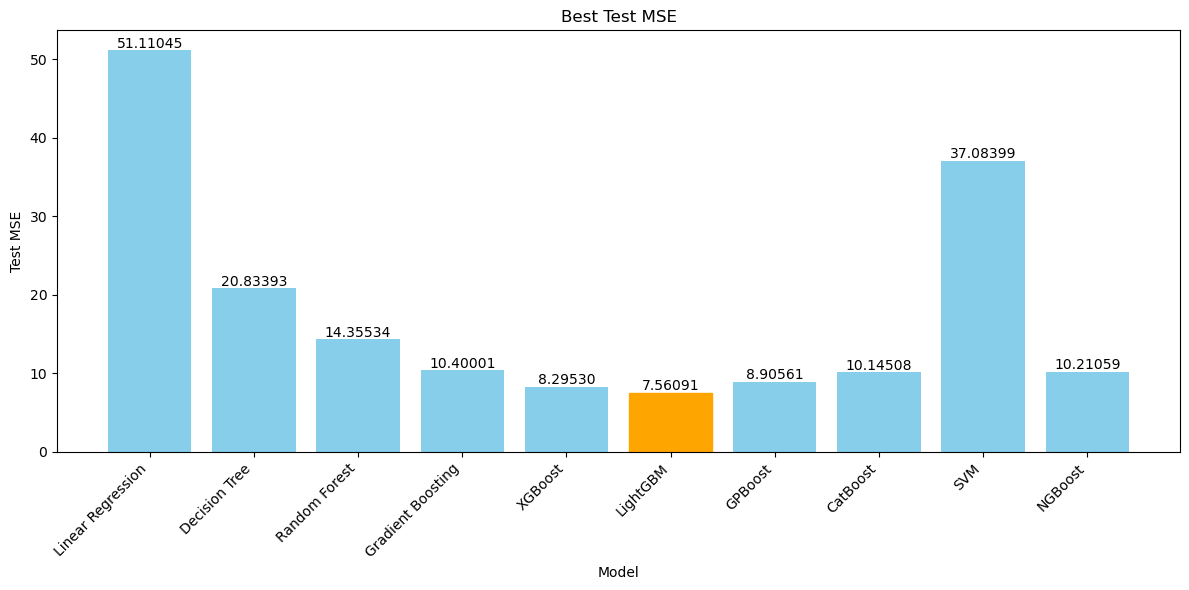

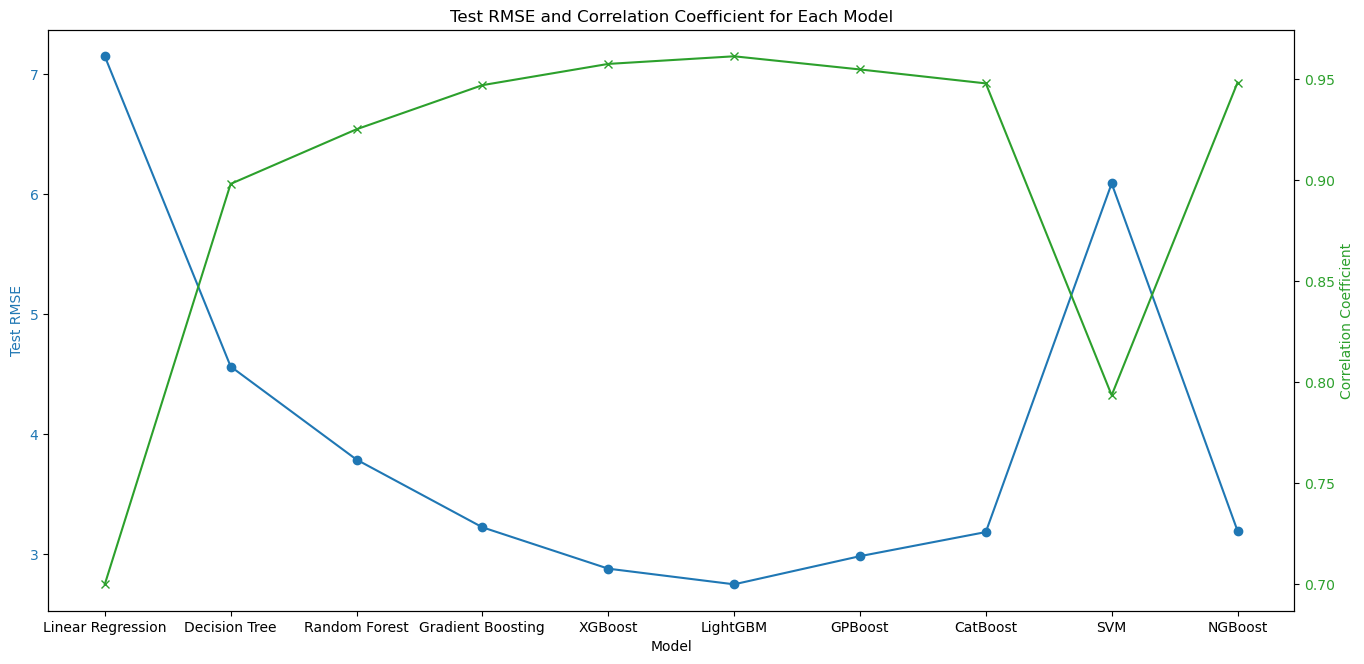

In [21]:
plot_best_scores(best_scores_bayes_opt)

# **Optuna**

In [22]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_optuna(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {key: trial.suggest_categorical(key, values) if isinstance(values, list) else trial.suggest_float(key, *values) for key, values in param_space.items()}

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Linear Regression': (LinearRegression, {
            'fit_intercept': [True, False],
            'copy_X': [True, False],
            'n_jobs': [-1, None],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor, {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR, {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7]
        })
    }

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        print(f"Running Optuna for {model_name}...")
        try:
            study = optuna.create_study(direction='minimize')
            study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

            best_params = study.best_params
            best_model = model_class().set_params(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Optuna for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_optuna = hyperparameter_tuning_optuna(X_train, y_train, X_test, y_test)

Running Optuna for Linear Regression...
Best MSE for Linear Regression: 51.01608458820771 with params: {'fit_intercept': True, 'copy_X': True, 'n_jobs': None, 'positive': False}
Best RMSE for Linear Regression: 7.142554486191037
Correlation Coefficient for Linear Regression: 0.7007087880671128
Running Optuna for Decision Tree...
Best MSE for Decision Tree: 27.06670093017087 with params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best RMSE for Decision Tree: 5.202566763643776
Correlation Coefficient for Decision Tree: 0.858794495401112
Running Optuna for Random Forest...
Best MSE for Random Forest: 11.07613332369179 with params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best RMSE for Random Forest: 3.328082529579426
Correlation Coefficient for Random Forest: 0.945505676066073
Running Optuna for Gradient Boosting...
Best MSE for Gradient Boosting: 8.364888492056137 with para

In [23]:
output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_optuna.csv"
predict_and_save_results(best_scores_optuna, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1
[iter 0] loss=3.7573 val_loss=0.0000 scale=1.0000 norm=8.5374
[iter 100] loss=1.4352 val_loss=0.0000 scale=1.0000 norm=1.1182
Predictions have been added to the CSV file.


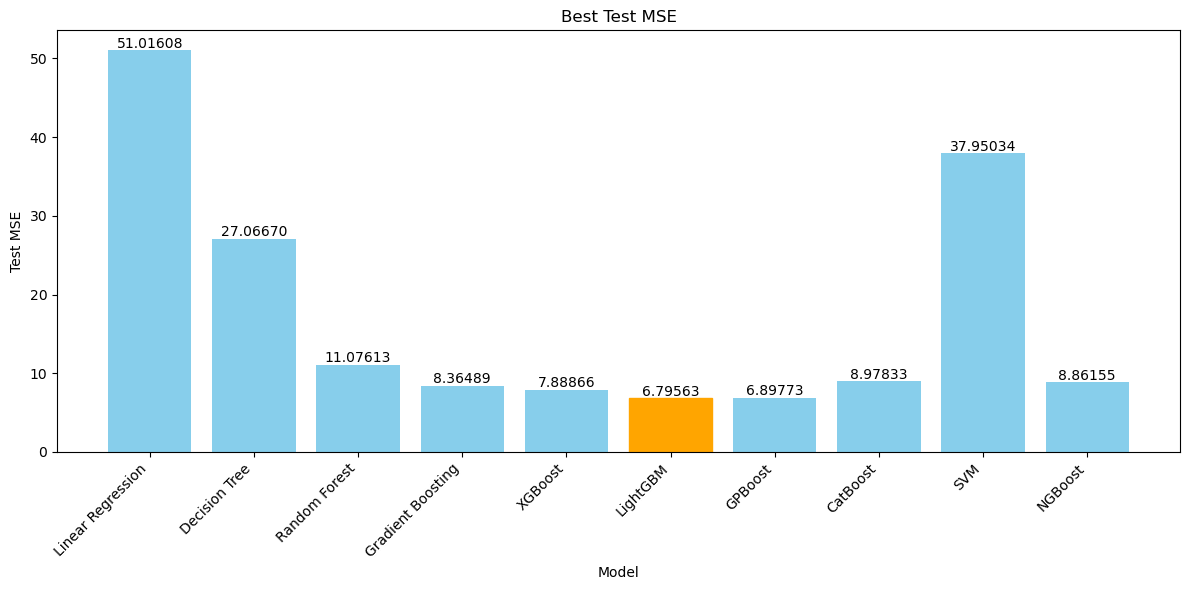

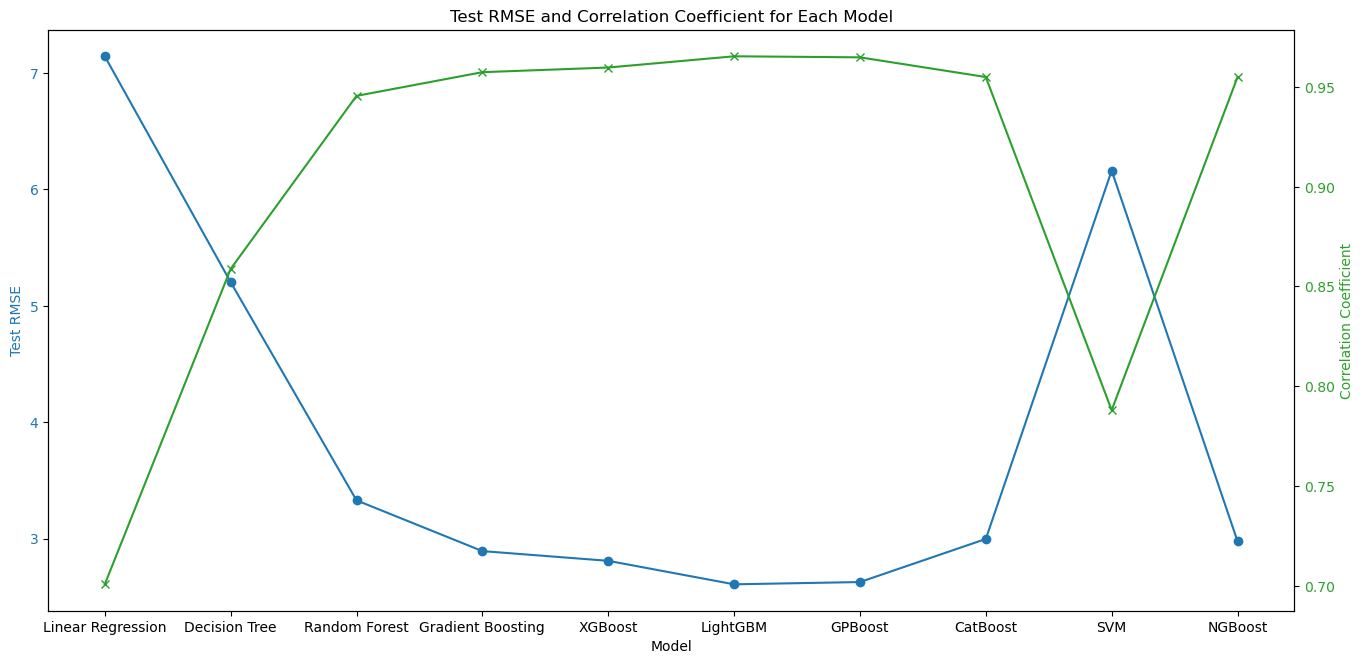

In [24]:
plot_best_scores(best_scores_ran= best_scores_optuna)

# **Hyper Opt**

In [25]:
def hyperparameter_tuning_hyperopt(X_train, y_train, X_test, y_test):
    def create_objective(model_class, param_space):
        def objective(params):
            try:
                model = model_class(**params)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                mse = mean_squared_error(y_test, y_pred)
                return {'loss': mse, 'status': STATUS_OK, 'params': params}
            except Exception as e:
                print(f"Error in model fitting: {e}")
                return {'loss': float('inf'), 'status': STATUS_OK}
        return objective

    # Define model configurations
    model_configs = {
        'Linear Regression': (LinearRegression, {
            'fit_intercept': hp.choice('fit_intercept', [True, False]),
            'positive': hp.choice('positive', [True, False])
        }),
        'Decision Tree': (DecisionTreeRegressor, {
            'max_depth': hp.choice('dt_max_depth', [None, 5, 10, 15]),
            'min_samples_split': hp.choice('dt_min_samples_split', [2, 5, 10]),
            'min_samples_leaf': hp.choice('dt_min_samples_leaf', [1, 2, 4]),
            'max_features': hp.choice('dt_max_features', ['sqrt', 'log2', None]),
            'random_state': 42
        }),
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': hp.choice('rf_n_estimators', [100, 200, 500]),
            'max_depth': hp.choice('rf_max_depth', [None, 5, 10, 15]),
            'min_samples_split': hp.choice('rf_min_samples_split', [2, 5, 10]),
            'min_samples_leaf': hp.choice('rf_min_samples_leaf', [1, 2, 4]),
            'max_features': hp.choice('rf_max_features', ['sqrt', 'log2', None]),
            'random_state': 42
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': hp.choice('gb_n_estimators', [100, 200, 500]),
            'learning_rate': hp.choice('gb_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('gb_max_depth', [3, 5, 10]),
            'min_samples_split': hp.choice('gb_min_samples_split', [2, 5, 10]),
            'min_samples_leaf': hp.choice('gb_min_samples_leaf', [1, 2, 4]),
            'max_features': hp.choice('gb_max_features', ['sqrt', 'log2']),
            'random_state': 42
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': hp.choice('xgb_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('xgb_max_depth', [3, 5, 7]),
            'n_estimators': hp.choice('xgb_n_estimators', [100, 200, 300, 500]),
            'min_child_weight': hp.choice('xgb_min_child_weight', [1, 3, 5]),
            'gamma': hp.choice('xgb_gamma', [0, 0.1, 0.5, 1]),
            'subsample': hp.choice('xgb_subsample', [0.5, 0.7, 0.9]),
            'colsample_bytree': hp.choice('xgb_colsample_bytree', [0.5, 0.7, 0.9]),
            'random_state': 42
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': hp.choice('lgbm_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('lgbm_max_depth', [3, 5, 7]),
            'n_estimators': hp.choice('lgbm_n_estimators', [100, 200, 300, 500]),
            'num_leaves': hp.choice('lgbm_num_leaves', [15, 31, 63]),
            'min_child_samples': hp.choice('lgbm_min_child_samples', [1, 5, 10]),
            'subsample': hp.choice('lgbm_subsample', [0.5, 0.7, 0.9]),
            'colsample_bytree': hp.choice('lgbm_colsample_bytree', [0.5, 0.7, 0.9]),
            'random_state': 42,
            'verbose': -1
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': hp.choice('gpboost_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('gpboost_max_depth', [3, 5, 7]),
            'n_estimators': hp.choice('gpboost_n_estimators', [100, 200, 300, 500]),
            'num_leaves': hp.choice('gpboost_num_leaves', [15, 31, 63]),
            'min_data_in_leaf': hp.choice('gpboost_min_data_in_leaf', [1, 5, 10]),
            'subsample': hp.choice('gpboost_subsample', [0.5, 0.7, 0.9]),
            'colsample_bytree': hp.choice('gpboost_colsample_bytree', [0.5, 0.7, 0.9]),
            'lambda_l2': hp.choice('gpboost_lambda_l2', [0.1, 0.5, 1.0]),
            'random_state': 42,
            'verbose': -1
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': hp.choice('catboost_learning_rate', [0.01, 0.05, 0.1]),
            'iterations': hp.choice('catboost_iterations', [100, 200, 300, 500]),
            'depth': hp.choice('catboost_depth', [3, 5, 7]),
            'l2_leaf_reg': hp.choice('catboost_l2_leaf_reg', [1, 3, 5]),
            'border_count': hp.choice('catboost_border_count', [32, 64, 128]),
            'random_state': 42
        }),
        'SVM': (SVR, {
            'kernel': hp.choice('svm_kernel', ['linear', 'rbf', 'poly']),
            'C': hp.loguniform('svm_C', np.log(0.1), np.log(10)),
            'gamma': hp.choice('svm_gamma', ['scale', 'auto']),
            'degree': hp.choice('svm_degree', [2, 3, 4]),
            'epsilon': hp.choice('svm_epsilon', [0.01, 0.1, 1])
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': hp.choice('ngb_n_estimators', [100, 200]),
            'learning_rate': hp.choice('ngb_learning_rate', [0.01, 0.1]),
            'natural_gradient': hp.choice('ngb_natural_gradient', [True, False]),
            'minibatch_frac': hp.choice('ngb_minibatch_frac', [0.5, 0.7]),
            'verbose': 0,
            'random_state': 42
        })
    }

    best_scores = {}

    for model_name, (model_class, param_space) in model_configs.items():
        print(f"\nOptimizing {model_name}...")
        try:
            # Create new trials for each model
            model_trials = Trials()

            # Run optimization for this model
            best = fmin(
                fn=create_objective(model_class, param_space),
                space=param_space,
                algo=tpe.suggest,
                max_evals=50,
                trials=model_trials,
                show_progressbar=False
            )

            # Use space_eval to get best parameters
            best_params = space_eval(param_space, best)

            # Create and train best model
            best_model = model_class(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }

            print(f"{model_name}:")
            print(f"Best Parameters: {best_params}")
            print(f"MSE: {mse:.6f}")
            print(f"RMSE: {rmse:.6f}")
            print(f"Correlation Coefficient: {corr_coef:.6f}")

        except Exception as e:
            print(f"Error optimizing {model_name}: {str(e)}")
            continue

    # Find the best overall model
    if best_scores:
        best_model_name = min(best_scores.keys(), key=lambda k: best_scores[k]['test_mse'])
        print(f"\nBest Overall Model: {best_model_name}")
        print(f"Best Overall MSE: {best_scores[best_model_name]['test_mse']:.6f}")
        print(f"Best Overall RMSE: {best_scores[best_model_name]['test_rmse']:.6f}")
        print(f"Best Overall Correlation Coefficient: {best_scores[best_model_name]['test_corr_coef']:.6f}")

    return best_scores

best_scores_hyperopt = hyperparameter_tuning_hyperopt(X_train, y_train, X_test, y_test)


Optimizing Linear Regression...
Linear Regression:
Best Parameters: {'fit_intercept': True, 'positive': False}
MSE: 51.016085
RMSE: 7.142554
Correlation Coefficient: 0.700709

Optimizing Decision Tree...
Decision Tree:
Best Parameters: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'random_state': 42}
MSE: 20.967310
RMSE: 4.579008
Correlation Coefficient: 0.902023

Optimizing Random Forest...
Random Forest:
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500, 'random_state': 42}
MSE: 11.412564
RMSE: 3.378249
Correlation Coefficient: 0.943383

Optimizing Gradient Boosting...
Gradient Boosting:
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 500, 'random_state': 42}
MSE: 7.660760
RMSE: 2.767808
Correlation Coefficient: 0.960823

Optimizing XGBoost...
XGBoost:
Best Parameters: {'c

In [26]:
output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_hyperopt.csv"
predict_and_save_results(best_scores_hyperopt, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[GPBoost] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
Predictions have been added to the CSV file.


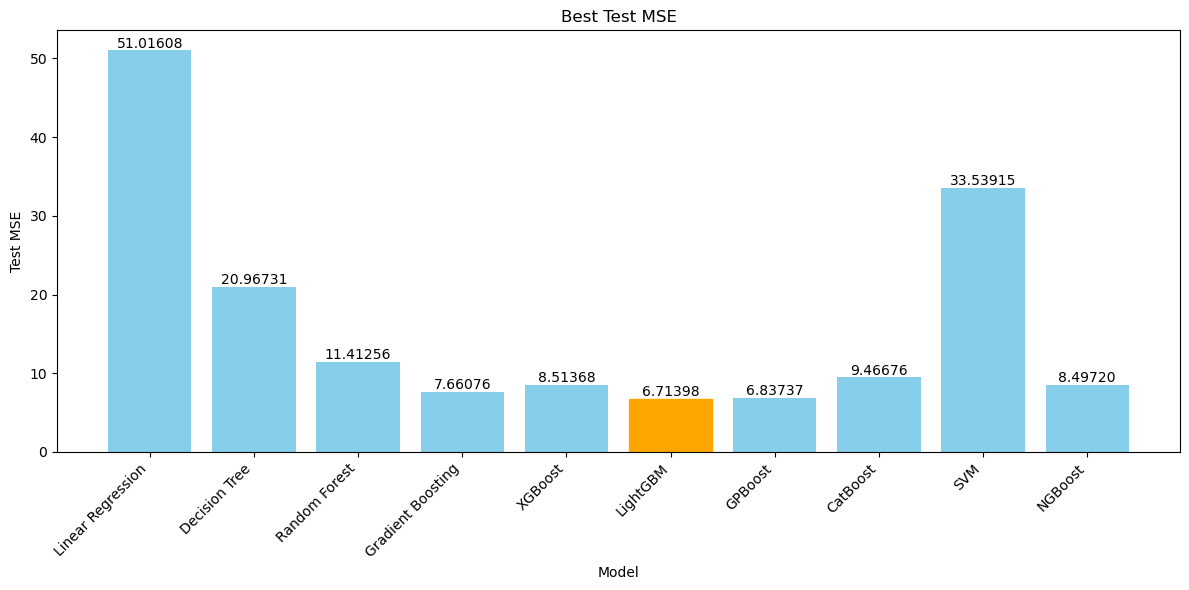

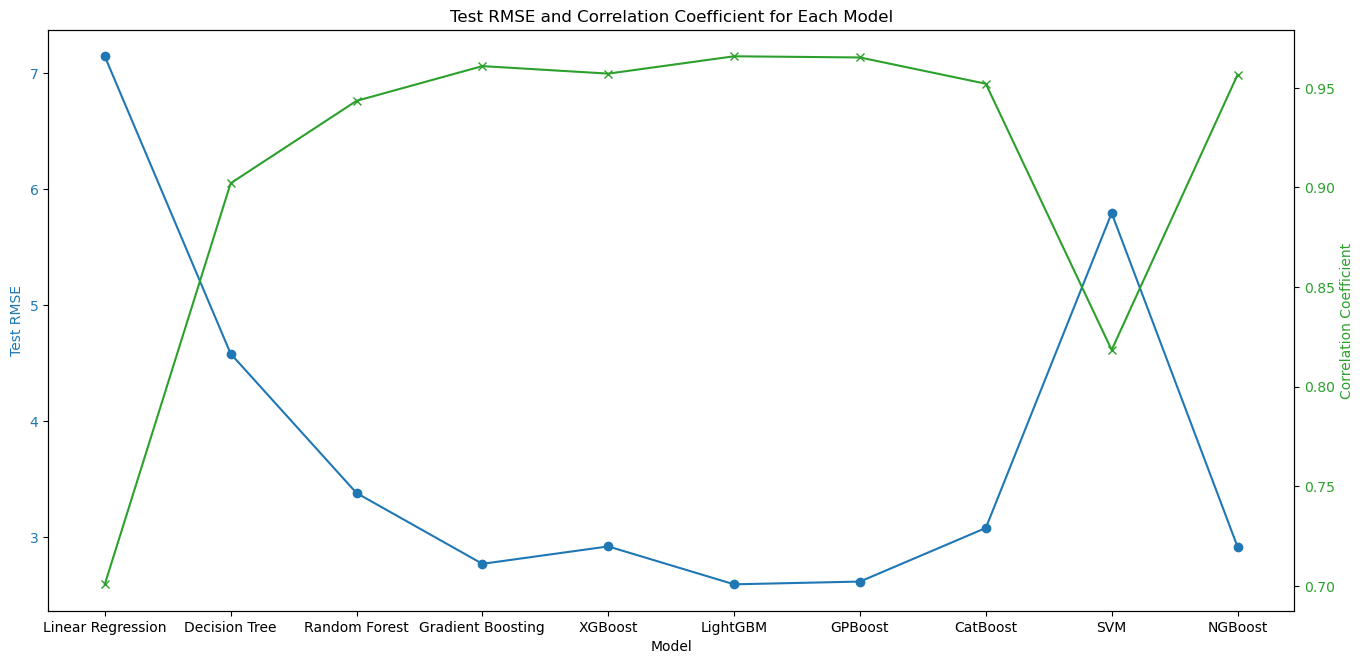

In [27]:
plot_best_scores(best_scores_ran= best_scores_hyperopt)

# **Halving GridSearchCV**

In [28]:
def hyperparameter_tuning_halving_grid(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': [True, False],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(verbosity=-1), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_data_in_leaf': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'lambda_l1': [0.0, 0.1, 0.5],
            'lambda_l2': [0.0, 0.1, 0.5]
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR(), {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor(verbose=0), {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        print(f"Running HalvingGridSearchCV for {model_name}...")
        try:
            search = HalvingGridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=3,
                factor=2,  # Reduction factor at each iteration
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=0
            )

            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run HalvingGridSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

# Example usage
best_scores_halving_grid = hyperparameter_tuning_halving_grid(X_train, y_train, X_test, y_test)

# Removing Warnings
warnings.filterwarnings('ignore', message='.*lambda_l2 is set with lambda.*')
warnings.filterwarnings('ignore', message='.*min_data_in_leaf is set.*')

Running HalvingGridSearchCV for Linear Regression...
Best MSE for Linear Regression: 51.11045031878047 with params: {'fit_intercept': True, 'positive': True}
Best RMSE for Linear Regression: 7.149157315291116
Correlation Coefficient for Linear Regression: 0.700080988482155
Running HalvingGridSearchCV for Decision Tree...
Best MSE for Decision Tree: 31.42692536683117 with params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5}
Best RMSE for Decision Tree: 5.605972294511557
Correlation Coefficient for Decision Tree: 0.8293935231123751
Running HalvingGridSearchCV for Random Forest...
Best MSE for Random Forest: 11.289185153337993 with params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE for Random Forest: 3.359938266298652
Correlation Coefficient for Random Forest: 0.9454133897477739
Running HalvingGridSearchCV for Gradient Boosting...
Best MSE for Gradient Boosting: 10.090

In [29]:
output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_halving_grid.csv"
predict_and_save_results(best_scores_halving_grid, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[GPBoost] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[GPBoost] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[iter 0] loss=3.7243 val_loss=0.0000 scale=0.5000 norm=0.4644
[iter 100] loss=3.1722 val_loss=0.0000 scale=0.5000 norm=0.2400
Predictions have been added to the CSV file.


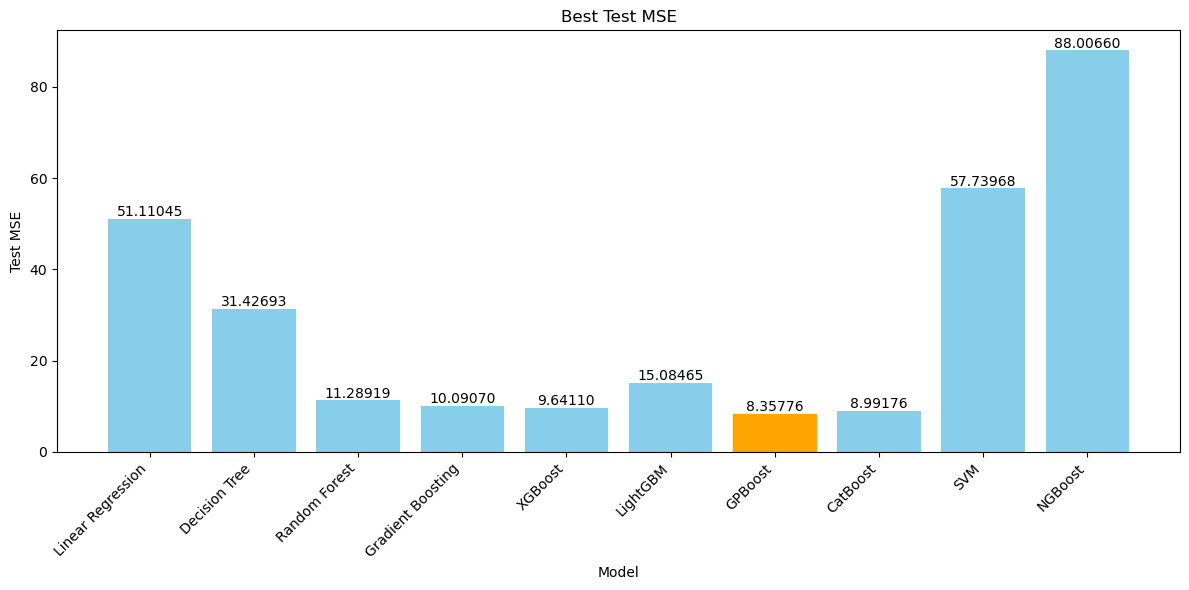

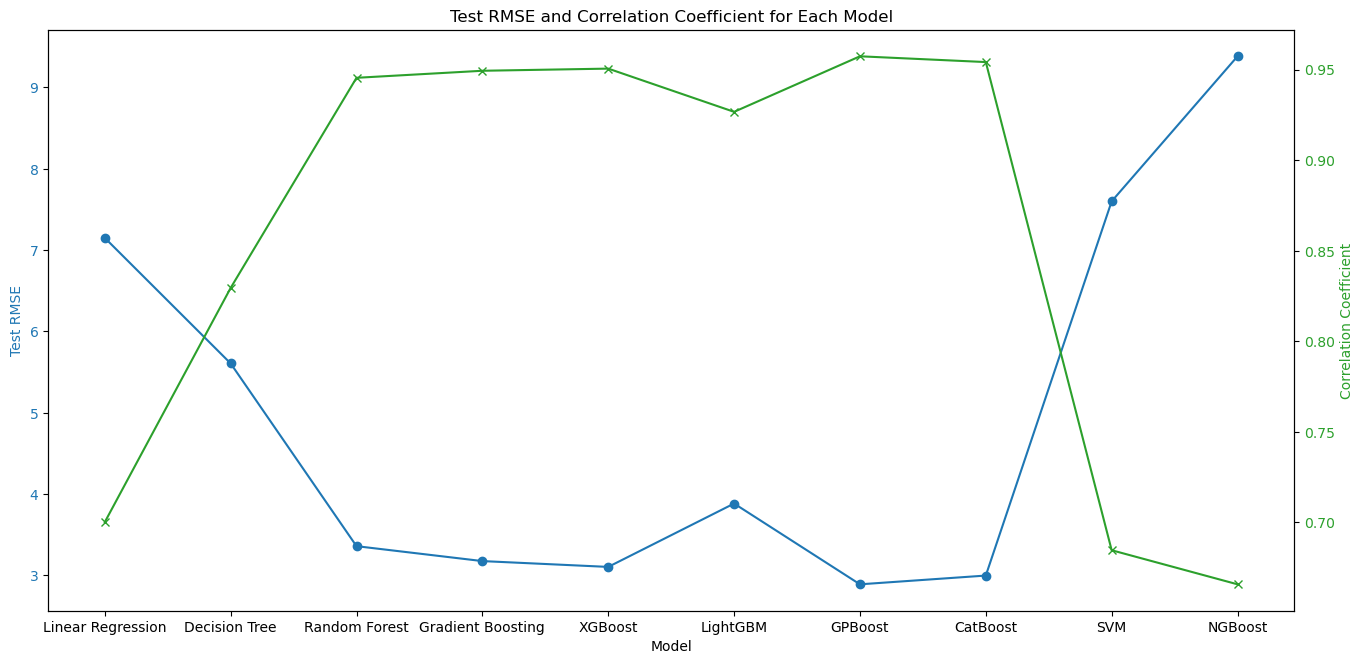

In [30]:
plot_best_scores(best_scores_ran= best_scores_halving_grid)

# **HyperBand**

In [31]:
def build_model(hp, model_type):
    model = keras.Sequential()
    input_shape = (X_train.shape[1],)

    activation_functions = [
         'tanh',
         'elu', 'selu',
        'softplus', 'softsign', 'hard_sigmoid'
    ]
    activation = activation_functions[model_type - 1]

    # Add a single dense layer with variable units and the chosen activation function
    model.add(keras.layers.Dense(
        units=hp.Int('units', min_value=32, max_value=512, step=32),
        activation=activation,
        input_shape=input_shape
    ))
    model.add(keras.layers.Dense(1))  # Output layer for regression

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='mse',
        metrics=['mse']
    )
    return model

# Create a dictionary of model types
model_types = {f'Model {i}': i for i in range(1, 7)}

# Function to tune and evaluate each model
def tune_and_evaluate(model_type, model_name):
    def model_builder(hp):
        return build_model(hp, model_type)

    tuner = Hyperband(
        model_builder,
        objective='val_mse',
        max_epochs=30,
        factor=3,
        directory='my_dir',
        project_name=f'intro_to_kt_{model_name}'
    )

    # Run the hyperparameter search
    tuner.search(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Build the model with the optimal hyperparameters and train it
    model = tuner.hypermodel.build(best_hps)
    model.fit(X_train, y_train, epochs=1, validation_split=0.2)

    # Evaluate the model
    y_pred = model.predict(X_test).flatten()  # Flatten the predictions
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

    print(f"{model_name} - Test MSE: {mse}")
    print(f"{model_name} - Test RMSE: {rmse}")
    print(f"{model_name} - Correlation Coefficient: {corr_coef}")

    return {
        'test_mse': mse,
        'test_rmse': rmse,
        'test_corr_coef': corr_coef,
        'best_parameters': best_hps.values
    }

# Tune and evaluate each model
results = {}
for model_name, model_type in model_types.items():
    results[model_name] = tune_and_evaluate(model_type, model_name)

# Compare results
best_model_name = min(results, key=lambda k: results[k]['test_mse'])  # Compare based on MSE
print(f"\nBest model: {best_model_name} with MSE: {results[best_model_name]['test_mse']}")
print(f"Best RMSE: {results[best_model_name]['test_rmse']}")
print(f"Best Correlation Coefficient: {results[best_model_name]['test_corr_coef']}")
print(f"Best hyperparameters: {results[best_model_name]['best_parameters']}")

Trial 66 Complete [00h 00m 05s]
val_mse: 1380.58984375

Best val_mse So Far: 73.60687255859375
Total elapsed time: 00h 04m 04s
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 1254.4048 - mse: 1254.4048 - val_loss: 789.4034 - val_mse: 789.4034
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Model 6 - Test MSE: 815.0679301214091
Model 6 - Test RMSE: 28.54939456663502
Model 6 - Correlation Coefficient: 0.38785163657385247

Best model: Model 4 with MSE: 504.85468557954056
Best RMSE: 22.46897161820141
Best Correlation Coefficient: 0.6035861846664385
Best hyperparameters: {'units': 448, 'learning_rate': 0.01, 'tuner/epochs': 30, 'tuner/initial_epoch': 10, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0048'}


In [32]:
import pandas as pd
import numpy as np
from keras_tuner.engine.hyperparameters import HyperParameters

# Function to predict and save results for Keras models
def predict_and_save_results(results, X_train, y_train, X_test, output_file_path):

    # Load the base DataFrame
    predictions_df = pd.read_csv(output_file_path)

    for model_name, model_info in results.items():
        best_params_dict = model_info['best_parameters']

        # Extract model_type from model_name (assuming 'Model 1', 'Model 2', etc.)
        model_type = int(model_name.split()[1])

        # Recreate the HyperParameters object and set the best hyperparameters
        hp = HyperParameters()
        for param_name, param_value in best_params_dict.items():
            if not param_name.startswith('tuner/'):  # Exclude 'tuner/' entries
                hp.Fixed(param_name, param_value)

        # Build the model with the best hyperparameters
        model = build_model(hp, model_type)

        # Retrieve the number of epochs used during tuning
        epochs = best_params_dict.get('tuner/epochs', 50)  # Default to 50 if not found

        # Train the model on the full training data
        model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0)

        # Make predictions on the test data
        y_pred = model.predict(X_test).flatten()

        # Add predictions to the DataFrame
        predictions_df[f'Sd_{model_name}'] = np.round(y_pred, 2)

    # Save the predictions to a CSV file at the specified location
    predictions_df.to_csv(output_file_path, index=False)
    print("Predictions have been added to the CSV file.")


output_file_path =r"C:\Users\Danesh\Desktop\ML Project\test_hyperband.csv"
predict_and_save_results(results, X_train, y_train, X_test, output_file_path)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predictions have been added to the CSV file.


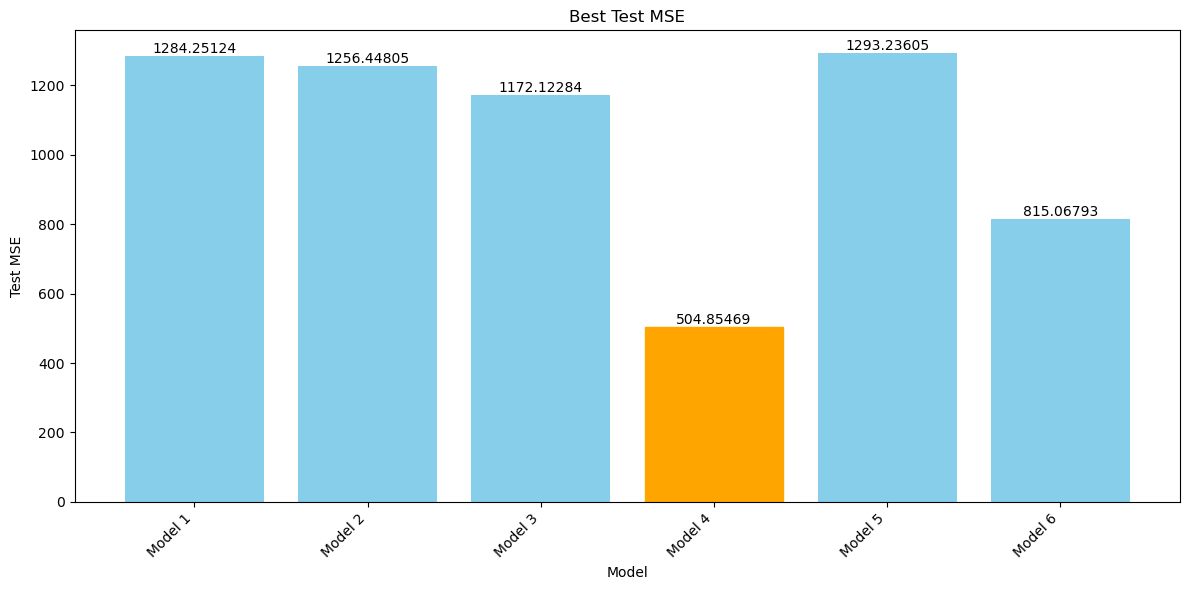

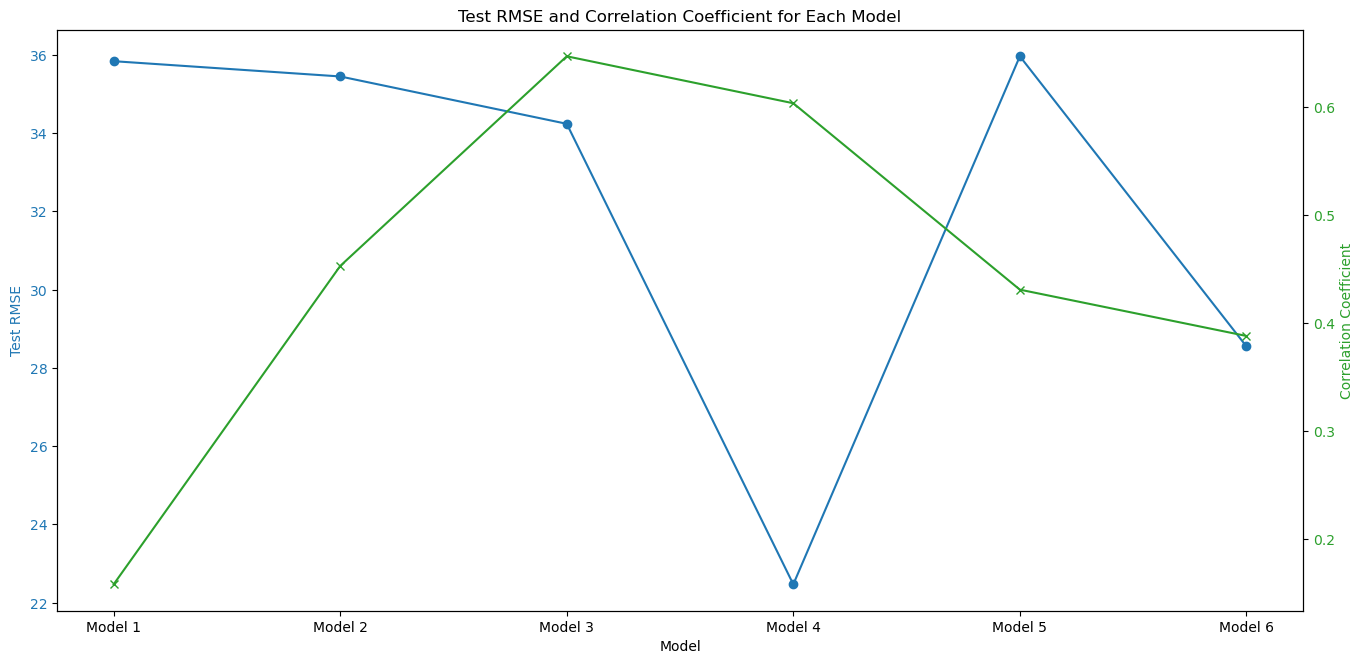

In [33]:
plot_best_scores(best_scores_ran= results)